In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fftpack import fft

Simulation Parameters

In [26]:
fs = 350 
timevec = np.arange(0, fs*7-1) / fs
npnts = len(timevec)
orig_sig = np.cumsum(np.random.randn(npnts)) # Brownian mothion (random walk)

Add noise and a 50 Hz sinusoidal component

In [27]:
y = orig_sig + 50*np.random.randn(npnts) + 40*np.sin(2*np.pi*50*timevec)

Compute the power spectrum

In [28]:
yX = np.abs(fft(y) / npnts) **2
hz = np.linspace(0, fs/2, int(np.floor(npnts/2) +1))

Plot the time-domain signal and power spectrum

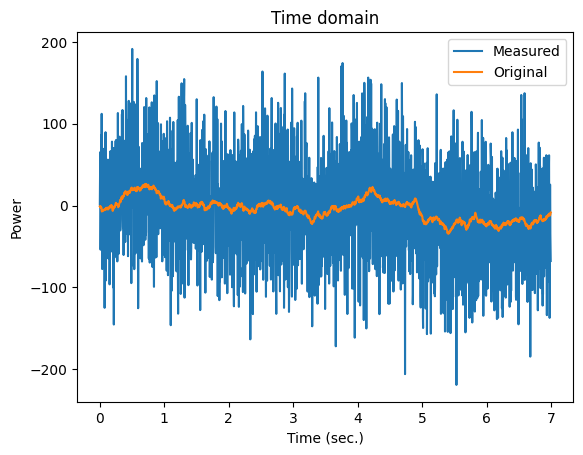

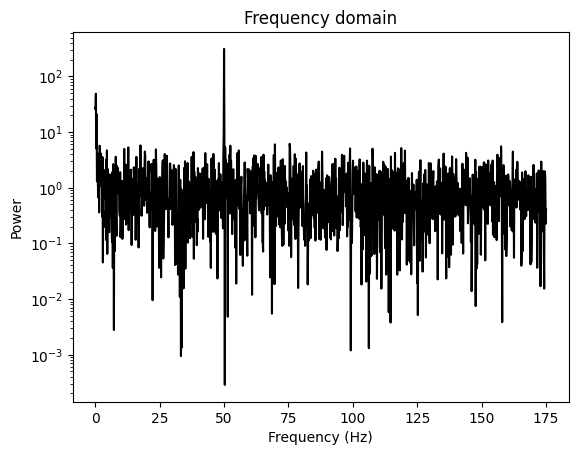

In [29]:
plt.plot(timevec, y, label='Measured')
plt.plot(timevec, orig_sig, label='Original')
plt.xlabel('Time (sec.)')
plt.ylabel('Power')
plt.title('Time domain')
plt.legend()
plt.show()

plt.plot(hz, yX[0:len(hz)], 'k')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Frequency domain')
plt.yscale('log')
plt.show()


Low pass filter

In [30]:
fcutoff = 30
transw = .2
order = np.round(7*fs/fcutoff)+1

Define filter shape

In [31]:
shape = [1,1,0,0]
frex = [0, fcutoff, fcutoff+fcutoff*transw, fs/2]

Design the filter kernel

In [32]:
filtkern = signal.firls(order, frex, shape, fs=fs)

Compute power spectrum

In [33]:
filtkernX = np.abs(fft(filtkern, npnts)) **2

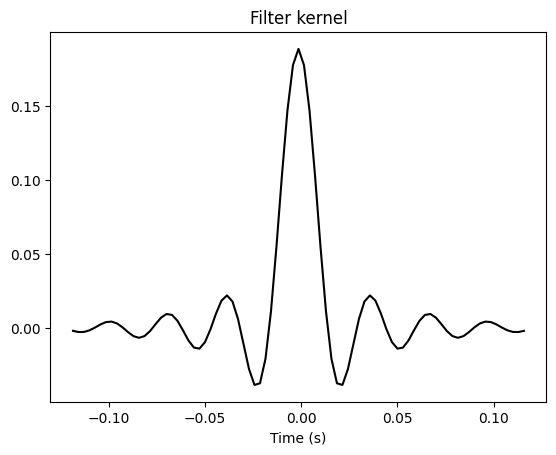

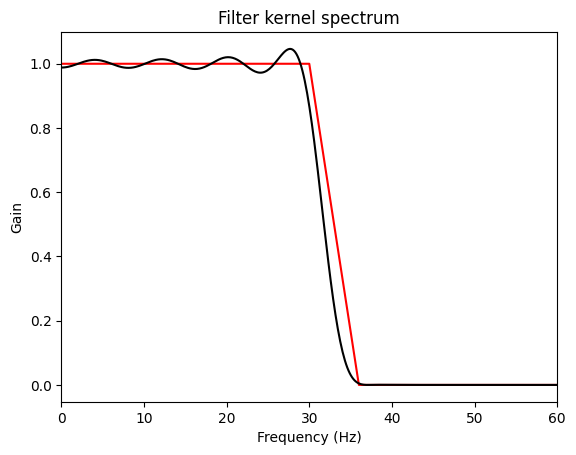

In [34]:
plt.plot(np.arange(-order/2, order/2) / fs, filtkern, 'k')
plt.xlabel('Time (s)')
plt.title('Filter kernel')
plt.show()
#freq response
plt.plot(np.array(frex), shape, 'r')  
plt.plot(hz, filtkernX[:len(hz)], 'k')  
plt.xlim([0, 60])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.title('Filter kernel spectrum')
plt.show()


Apply the filter to the signal

In [35]:
yFilt = signal.filtfilt(filtkern, 1, y) #filtfilt applies the filter forward and backward to avoid distortion

Plot the original and filtered signals

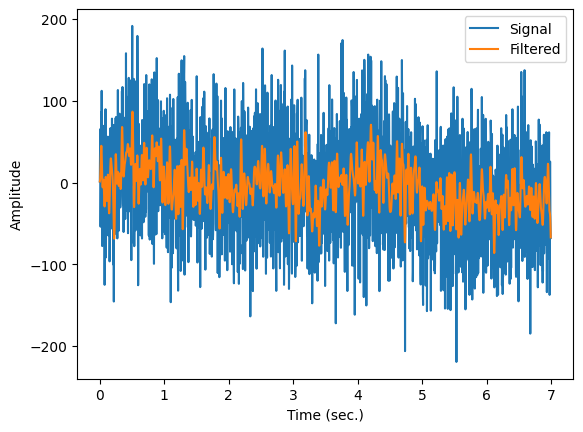

In [36]:
plt.plot(timevec, y, label='Signal')
plt.plot(timevec, yFilt, label='Filtered')
plt.legend()
plt.xlabel('Time (sec.)')
plt.ylabel('Amplitude')
plt.show()

Compute and plot power spectra

In [37]:
yOrigX = np.abs(fft(y) / npnts)**2
yFiltX = np.abs(fft(yFilt) / npnts)**2


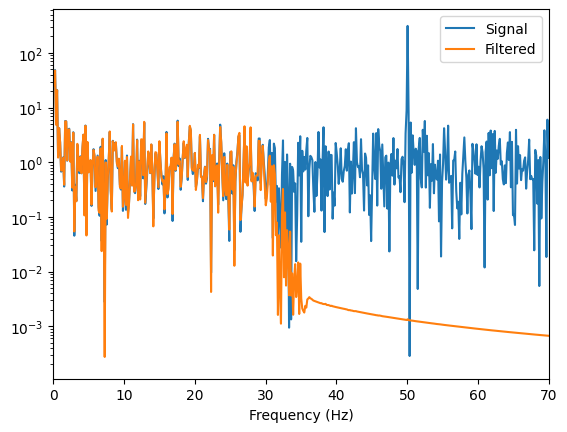

In [38]:
plt.plot(hz, yOrigX[:len(hz)], label='Signal')
plt.plot(hz, yFiltX[:len(hz)], label='Filtered')
plt.xlim([0, fs/5])
plt.yscale('log')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.show()
